# Critical bubble by the shooting method

Units: T0 = 1, and phi, r and T are measured in these units.

In [1]:
import numpy as np
import math
import os
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.optimize import brentq

## 1. The potential

$V(\phi,T) = D(T^2-T_0^2)\phi^2 - E\,T\,\phi^3 + \tfrac{\lambda}{4}\phi^4$

In [107]:
lam, D, E, T0 = 0.1, 0.1, 0.05, 1.0

# Analytic critical values from the derivation
Tc = math.sqrt(T0**2 / (1 - (E ** 2 / (lam * D))))
phic = 2 * E * Tc / lam
sigma = math.sqrt(lam/2) * phic**3 / 6

In [108]:
def V(phi, T):
    return (D * (T ** 2 - T0 ** 2) * phi ** 2 - E * T * phi ** 3 + (lam / 4) * phi ** 4)
    
def dV(phi, T):
    return (D * (T ** 2 - T0 ** 2) * phi * 2 - 3 * E * T * phi ** 2 + lam * phi ** 3)

### Check

In [98]:
h = 1e-6
phi, T = 0.8, 1.1
print(dV(phi, T), (V(phi + h, T) - V(phi - h, T)) / (2 * h))

-0.020799999999999992 -0.0208000000053582


In [116]:
def disc2(T):
    a, b, c = lam, (-3 * E * T), 2 * D * (T ** 2 - T0 ** 2)
    return b**2 - 4 * a * c
    
def extrema(T): # solve lam*phi^2 - 3*E*T*phi + 2*D*(T^2-T0^2) = 0 with the quadratic formula.
    a, b, c = lam, (-3 * E * T), 2 * D * (T ** 2 - T0 ** 2) 
    disc = b**2 - 4 * a * c
    if disc >= 0:
        phi_m, phi_p = ((-b - math.sqrt(disc)) / (2 * a)), ((-b + math.sqrt(disc)) / (2 * a))
        return phi_m, phi_p
    else:
        return None

### Check

In [117]:
T = 1.12
pm, pp = extrema(T)
T1 = brentq(disc2,1.0,1.5)
print(dV(pm, T), dV(pp, T), T1, (Tc+T0)/2)
print(Tc, phic, sigma)

8.673617379884035e-19 -2.7755575615628914e-17 1.179535649239177 1.0773502691896257
1.1547005383792515 1.1547005383792515 0.057377531054924685


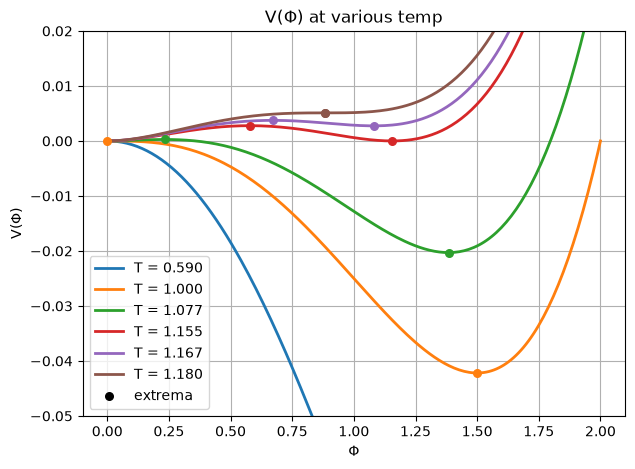

In [139]:
temp = [T1/2, T0, (Tc+T0)/2, Tc, ((T1 + Tc) / 2), T1]
x = np.linspace(0.0, 2, 200)
plt.figure(figsize = (7,5))
for t in temp: 
    (line,) = plt.plot(x, V(x, t), linewidth = 2, label = f"T = {t:.3f}")

    for p in extrema(t):
        if p >=0:
            plt.scatter(p, V(p, t), s = 30, zorder = 5, color = line.get_color())

plt.ylim(-0.05, 0.02)
# plt.ylim(-0.01,0.01) # use this one to see the barrier near T_c clearly
plt.title("V(Φ) at various temp")
plt.xlabel("Φ")
plt.ylabel("V(Φ)")
plt.grid(True)
plt.scatter([], [], s=30, color='k', label='extrema')
plt.legend()
plt.savefig("figures/V_at_various_Temp.png", dpi=300, bbox_inches="tight")
plt.show()

## 2. The integrator

Equation: $\phi'' + \tfrac{2}{r}\phi' = V'(\phi)$. Writing it as a first-order system $\Phi=(\phi,\phi')$:
$\Phi_0' = \Phi_1$ and $\Phi_1' = V'(\Phi_0) - \tfrac{2}{r}\Phi_1$.



The false vacuum is at $\phi = 0$. Two events stop the integration:
- **overshoot**: $\phi$ crosses 0 going downward (event function `Phi[0]`, direction -1),
- **undershoot**: $\phi'$ becomes positive (event function `Phi[1]`, direction +1).

In [52]:
def shoot(phi0, T, rmax = 400.0, r0 = 1e-4, rtol = 1e-10, atol = 1e-12):
    # Integrate from r0 with initial value phi0. Return (flag, sol): flag = +1 overshoot, -1 undershoot, 0 neither before rmax.
    c = dV(phi0, T)
    Phi0  = [phi0 + c * r0 ** 2 / 6, c * r0 / 3]

    def rhs(r, Phi):
        # return [Phi[0]', Phi[1]'] as above
        return [Phi[1], (dV(Phi[0], T) - 2 * Phi[1] / r)]

    def over(r, Phi):  return Phi[0]
    over.terminal, over.direction = True, -1
    def under(r, Phi): return Phi[1]
    under.terminal, under.direction = True, 1

    sol = solve_ivp(rhs, [r0, rmax], Phi0, events = [over, under], rtol = rtol, atol = atol, dense_output = True)
    if sol.t_events[0].size: return +1, sol
    if sol.t_events[1].size: return -1, sol
    return 0, sol

### Check

In [53]:
for phi0 in np.linspace(1.2, pp, 11)[:-1]:
    print(f"{phi0:.4f}", shoot(phi0, 1.12)[0])

1.2000 -1
1.2084 -1
1.2167 -1
1.2251 -1
1.2334 1
1.2418 1
1.2502 1
1.2585 1
1.2669 1
1.2753 1


## 3. Bisection on phi0

Overshoot means phi0 is too close to the broken minimum, so lower `hi`. Undershoot means raise `lo`.

In [78]:
def bounce(t, r0 = 1e-4, tol=1e-12, rtol = 1e-10, off = 1e-13):
    pm, pp = extrema(t)
    lo = pm + off*(pp - pm)
    hi = pp - off*(pp - pm)
    assert shoot(lo, t , r0 = r0, rtol = rtol)[0] < 0 and shoot(hi, t , r0 = r0, rtol = rtol)[0] > 0, "bracket failed"
    for _ in range(200):
        mid = (lo + hi) / 2
        flag, _ = shoot(mid, t , r0 = r0, rtol = rtol)
        if flag > 0:
            hi = mid
        else :
            lo = mid
        if (hi - lo) < (tol * pp):
            break
    phi0 = (lo + hi) / 2
    flag, sol = shoot(phi0, t , r0 = r0, rtol = rtol)
    if flag == 0:
        raise RuntimeError(f"T={t}: no event before rmax; raise rmax or check the bracket")
    return phi0, sol

### Check

In [79]:
phi0, sol = bounce(1.12, tol = 1e-14)
print(phi0, sol.t[-1])
phi0, sol = bounce(1.15, tol = 1e-14)
print(phi0, sol.t[-1])

1.2320871932148192 95.66216245600495
1.1769936406284756 146.9421227625337


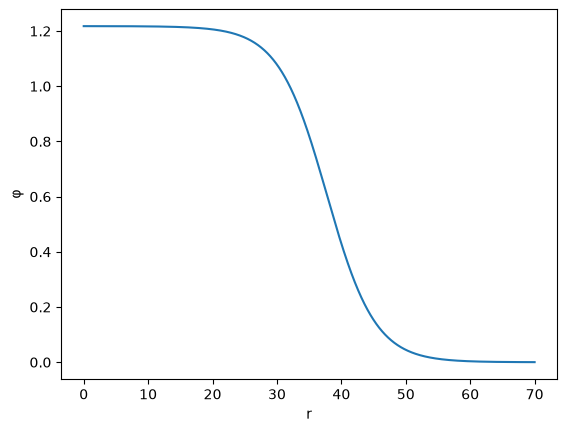

In [87]:
r = np.linspace(1e-4, min(70, sol.t[-1]), 2000)
plt.plot(r, sol.sol(r)[0]); plt.xlabel("r"); plt.ylabel("φ")
plt.savefig("figures/phi0sol.png", dpi = 300, bbox_inches = "tight")
plt.show()

### Bubble Profile

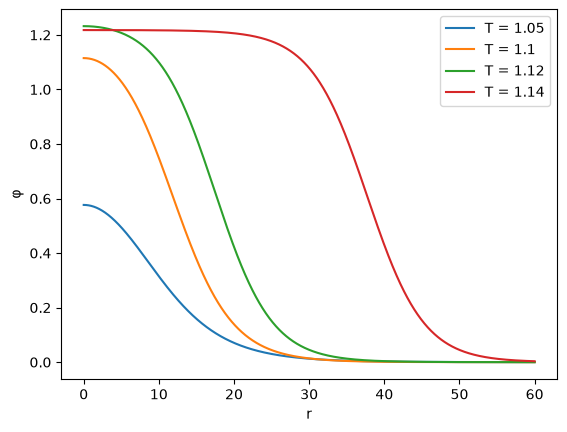

In [81]:
r = np.linspace(1e-4, min(60, sol.t[-1]), 2000)
for t in [1.05,1.10, 1.12, 1.14]:
    phi0, sol = bounce(t)
    plt.plot(r, sol.sol(r)[0], label = f"T = {t}")

plt.xlabel("r")
plt.ylabel("φ")
plt.legend()
plt.savefig("figures/bubble_profile.png", dpi = 300, bbox_inches = "tight")
plt.show()

## 4. The action

$S_3 = 4\pi\int r^2\,[\tfrac12\phi'^2 + V]\,dr$ (here $V(0,T)=0$). Used `np.trapezoid` on a fine grid.
Also computes the kinetic part $K = 4\pi\int r^2\,\tfrac12\phi'^2\,dr$ and the potential part $P$ separately.

In [88]:
def action(T, r0 = 1e-4, tol = 1e-12, rtol=1e-10):
    phi0, sol = bounce(T, r0 = r0, tol=tol, rtol = rtol)
    r = np.linspace(sol.t[0], sol.t[-1], 200001)
    Phi = sol.sol(r)
    K = 4 * np.pi * np.trapezoid(r ** 2 * 0.5 * Phi[1] ** 2, r) # 4pi∫r^2 (1/2)phi'^2 dr
    P = 4 * np.pi * np.trapezoid(r ** 2 * V(Phi[0], T), r) # 4pi∫r^2 V(phi,T) dr
    return ((K + P), K, P, phi0, sol.t[-1])

## 5. Validation

### (a) Virial identity. 
For an O(3) bounce, rescaling $r$ in the action requires $K + 3P = 0$, hence $S_3 = \tfrac{2}{3}K$.

In [136]:
for t in [1.05,1.10, 1.12, 1.14, 1.145, 1.15]:
    S3, K, P, phi0, rend = action(t, tol = 1e-14)
    print(f"T = {t} | S_3 = {S3:.5f} | S_3 / T = {S3 / t:.5f} | K + 3 * P = {K + 3 * P} | S3 = {S3:.5f} | 2 / 3 * K = {2 / 3 * K:.5f}")

T = 1.05 | S_3 = 7.74814 | S_3 / T = 7.37919 | K + 3 * P = 3.9668712759066693e-10 | S3 = 7.74814 | 2 / 3 * K = 7.74814
T = 1.1 | S_3 = 41.67990 | S_3 / T = 37.89082 | K + 3 * P = -7.656950629097992e-10 | S3 = 41.67990 | 2 / 3 * K = 41.67990
T = 1.12 | S_3 = 93.24405 | S_3 / T = 83.25362 | K + 3 * P = -2.3424519213222084e-08 | S3 = 93.24405 | 2 / 3 * K = 93.24405
T = 1.14 | S_3 = 396.47923 | S_3 / T = 347.78880 | K + 3 * P = -2.356294999117381e-07 | S3 = 396.47923 | 2 / 3 * K = 396.47923
T = 1.145 | S_3 = 821.25180 | S_3 / T = 717.25048 | K + 3 * P = -5.169570158614079e-07 | S3 = 821.25180 | 2 / 3 * K = 821.25180
T = 1.15 | S_3 = 3090.81203 | S_3 / T = 2687.66264 | K + 3 * P = 0.03487096322260186 | S3 = 3090.81203 | 2 / 3 * K = 3090.80041


### (b) Convergence.
Vary `rtol` (1e-6, 1e-8, 1e-10, 1e-12) and `r0` (1e-2 to 1e-5) at T = 1.12 and tabulate S3.

In [90]:
for rtol in [1e-6, 1e-8, 1e-10, 1e-12]:
    S3, K, P, phi0, rend = action(1.12, rtol = rtol)
    print(f"rtol = {rtol} | S_3 = {S3} | S_3 / T = {S3 / 1.12} | K + 3 * P = {K + 3 * P} | S3 = {S3} | 2 / 3 * K = {2 / 3 * K}")

for r0 in np.linspace(1e-5, 1e-2, 4):
    S3, K, P, phi0, rend = action(1.12, r0 = r0)
    print(f"r0 = {r0} | S_3 = {S3} | S_3 / T = {S3 / 1.12} | K + 3 * P = {K + 3 * P} | S3 = {S3} | 2 / 3 * K = {2 / 3 * K}")

rtol = 1e-06 | S_3 = 93.24407044807293 | S_3 / T = 83.25363432863654 | K + 3 * P = -0.0005235873141202774 | S3 = 93.24407044807293 | 2 / 3 * K = 93.24424497717764
rtol = 1e-08 | S_3 = 93.24405351426444 | S_3 / T = 83.25361920916467 | K + 3 * P = -3.437919758653152e-06 | S3 = 93.24405351426444 | 2 / 3 * K = 93.2440546602377
rtol = 1e-10 | S_3 = 93.24405330288563 | S_3 / T = 83.25361902043359 | K + 3 * P = -2.0346902829260216e-08 | S3 = 93.24405330288563 | 2 / 3 * K = 93.24405330966792
rtol = 1e-12 | S_3 = 93.24405330042852 | S_3 / T = 83.25361901823975 | K + 3 * P = -7.875371466070646e-10 | S3 = 93.24405330042852 | 2 / 3 * K = 93.24405330069102
r0 = 1e-05 | S_3 = 93.24405330288488 | S_3 / T = 83.25361902043292 | K + 3 * P = -2.0338262629593373e-08 | S3 = 93.24405330288488 | 2 / 3 * K = 93.24405330966431
r0 = 0.00334 | S_3 = 93.24405330429775 | S_3 / T = 83.25361902169442 | K + 3 * P = -2.2038705083105015e-08 | S3 = 93.24405330429775 | 2 / 3 * K = 93.24405331164397
r0 = 0.00667 | S_3 = 9

### (c) Thin-wall limit.
Near Tc, $S_3 \to 16\pi\sigma^3/(3\varepsilon^2)$ with $\varepsilon = V(0)-V(\phi_+)$.
Computing the ratio S3/S3_thin for T = 1.14, 1.145, 1.15.

**Warning for (c).** The bubble radius is about $2\sigma/\varepsilon$. Near Tc it becomes so large that the shooting
cannot follow it in double precision (the solution is exponentially sensitive to phi0). For T above about 1.150 your S3 will
silently come out too small, because the integration stopped before the bubble wall. Comparing the integration end
`sol.t[-1]` with $2\sigma/\varepsilon$. If the end is smaller than that, the result is not valid.

In [100]:
def action_thin(T):
    pm, pp = extrema(T)
    ep = V(0,T) - V(pp,T)
    bub_rad = 2 * sigma / ep
    return (16 * np.pi * sigma ** 3 / (3 * ep ** 2), bub_rad)

In [125]:
for t in [1.14, 1.145, 1.15]:
    S3, K, P, phi0, rend = action(t, tol = 1e-14)
    S_thin, bub_rad = action_thin(t)
    assert rend > bub_rad, "Invalid Result, radius beyond shooting limit"
    print(f"|T = {t} | S3 = {S3:.3f} | S_thin = {S_thin:.3f} | ratio = {S3 / S_thin:.4f} | (ratio-1) * R = {(S3 / S_thin - 1) * bub_rad:.5f} | rend = {rend:.1f} | 2σ/ε = {bub_rad:.1f}|")

|T = 1.14 | S3 = 396.479 | S_thin = 254.330 | ratio = 1.5589 | (ratio-1) * R = 18.18151 | rend = 111.1 | 2σ/ε = 32.5|
|T = 1.145 | S3 = 821.252 | S_thin = 598.041 | ratio = 1.3732 | (ratio-1) * R = 18.61808 | rend = 114.4 | 2σ/ε = 49.9|
|T = 1.15 | S3 = 3090.812 | S_thin = 2614.126 | ratio = 1.1824 | (ratio-1) * R = 19.01752 | rend = 146.9 | 2σ/ε = 104.3|


T = 1.130 | S3 = 164.735 | S_thin = 86.434 | ratio = 1.9059 | (ratio-1) * R = 17.17940 | rend = 97.9 | 2σ/ε = 19.0
T = 1.132 | S3 = 192.882 | S_thin = 105.269 | ratio = 1.8323 | (ratio-1) * R = 17.41803 | rend = 97.3 | 2σ/ε = 20.9
T = 1.134 | S3 = 229.739 | S_thin = 130.795 | ratio = 1.7565 | (ratio-1) * R = 17.64731 | rend = 97.7 | 2σ/ε = 23.3
T = 1.137 | S3 = 279.597 | S_thin = 166.552 | ratio = 1.6787 | (ratio-1) * R = 17.86753 | rend = 103.9 | 2σ/ε = 26.3
T = 1.139 | S3 = 349.843 | S_thin = 218.754 | ratio = 1.5993 | (ratio-1) * R = 18.07897 | rend = 101.1 | 2σ/ε = 30.2
T = 1.141 | S3 = 454.143 | S_thin = 299.130 | ratio = 1.5182 | (ratio-1) * R = 18.28199 | rend = 108.9 | 2σ/ε = 35.3
T = 1.143 | S3 = 620.278 | S_thin = 432.005 | ratio = 1.4358 | (ratio-1) * R = 18.47694 | rend = 108.7 | 2σ/ε = 42.4
T = 1.146 | S3 = 912.459 | S_thin = 674.773 | ratio = 1.3522 | (ratio-1) * R = 18.66420 | rend = 118.0 | 2σ/ε = 53.0
T = 1.148 | S3 = 1509.790 | S_thin = 1190.971 | ratio = 1.2677 | (ra

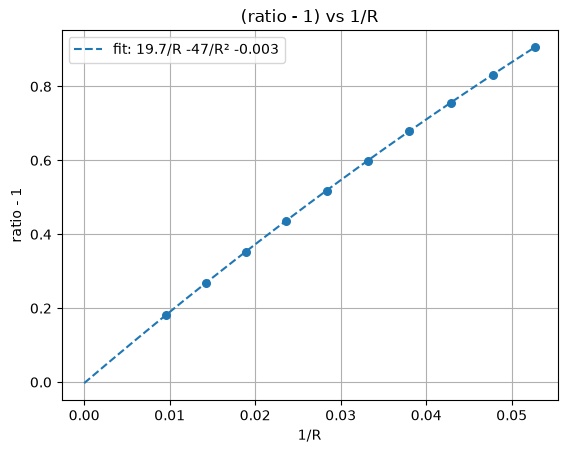

In [135]:
xs = []
ys = []
for t in np.linspace(1.13, 1.15, 10):
    S3, K, P, phi0, rend = action(t, tol = 1e-14)
    S_thin, bub_rad = action_thin(t)
    assert rend > bub_rad, "Invalid Result, radius beyond shooting limit"
    print(f"T = {t:.3f} | S3 = {S3:.3f} | S_thin = {S_thin:.3f} | ratio = {S3 / S_thin:.4f} | (ratio-1) * R = {(S3 / S_thin - 1) * bub_rad:.5f} | rend = {rend:.1f} | 2σ/ε = {bub_rad:.1f}")
    xs.append(1/bub_rad)
    ys.append(S3/S_thin - 1)
    plt.scatter(1 / bub_rad, (S3 / S_thin - 1), s = 30, zorder = 5, color = (0.12156862745098039, 0.4666666666666667, 0.7058823529411765))

xs, ys = np.array(xs), np.array(ys)
p = np.polyfit(xs, ys, 2)
xx = np.linspace(0, xs.max(), 200)
plt.plot(xx, np.polyval(p, xx), "--", label=f"fit: {p[1]:.1f}/R {p[0]:+.0f}/R² {p[2]:+.3f}")
plt.legend()

plt.title("(ratio - 1) vs 1/R")
plt.xlabel("1/R")
plt.ylabel("ratio - 1")
plt.grid(True)
plt.savefig("figures/ratio_1byR_behaviour.png", dpi=300, bbox_inches="tight")
plt.show()